# Boolean Retrieval with Shakespeare (Exact Match)
# INFO 376 - Lecture 2


In the **Boolean Retrieval model**, documents are either relevant or not.  
There is no "degree of match" – it’s **yes/no**.  

- Queries use Boolean operators: **AND, OR, NOT**  
- Documents are treated as sets of words (terms)  
- Retrieval = set operations on postings lists  

We’ll use a **synthetic Shakespeare dataset** to see how Exact Match works.


In [1]:
documents = {
    1: "Brutus and Caesar were seen in the marketplace.",
    2: "Calpurnia warned Caesar about the ides of March.",
    3: "Hamlet spoke to the ghost in the castle.",
    4: "Antony and Cleopatra ruled Egypt together.",
    5: "Brutus plotted against Caesar with the conspirators."
}

for doc_id, text in documents.items():
    print(f"Doc {doc_id}: {text}")


Doc 1: Brutus and Caesar were seen in the marketplace.
Doc 2: Calpurnia warned Caesar about the ides of March.
Doc 3: Hamlet spoke to the ghost in the castle.
Doc 4: Antony and Cleopatra ruled Egypt together.
Doc 5: Brutus plotted against Caesar with the conspirators.


In [2]:
import re

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

tokens = {doc_id: tokenize(text) for doc_id, text in documents.items()}
tokens


{1: ['brutus', 'and', 'caesar', 'were', 'seen', 'in', 'the', 'marketplace'],
 2: ['calpurnia', 'warned', 'caesar', 'about', 'the', 'ides', 'of', 'march'],
 3: ['hamlet', 'spoke', 'to', 'the', 'ghost', 'in', 'the', 'castle'],
 4: ['antony', 'and', 'cleopatra', 'ruled', 'egypt', 'together'],
 5: ['brutus', 'plotted', 'against', 'caesar', 'with', 'the', 'conspirators']}

In [3]:
import pandas as pd

# Build vocabulary
vocab = sorted(set(term for doc in tokens.values() for term in doc))

# Build incidence matrix
matrix = pd.DataFrame(0, index=vocab, columns=documents.keys())
for doc_id, words in tokens.items():
    for w in set(words):
        matrix.loc[w, doc_id] = 1

matrix


,1,2,3,4,5
about,0,1,0,0,0
against,0,0,0,0,1
and,1,0,0,1,0
antony,0,0,0,1,0
brutus,1,0,0,0,1
caesar,1,1,0,0,1
calpurnia,0,1,0,0,0
castle,0,0,1,0,0
cleopatra,0,0,0,1,0
conspirators,0,0,0,0,1


In [5]:
from collections import defaultdict

inverted_index = defaultdict(list)
for doc_id, words in tokens.items():
    for w in set(words):
        inverted_index[w].append(doc_id)

inverted_index = {k: sorted(v) for k,v in inverted_index.items()}
inverted_index


{'brutus': [1, 5],
 'caesar': [1, 2, 5],
 'seen': [1],
 'in': [1, 3],
 'and': [1, 4],
 'marketplace': [1],
 'the': [1, 2, 3, 5],
 'were': [1],
 'calpurnia': [2],
 'about': [2],
 'march': [2],
 'warned': [2],
 'ides': [2],
 'of': [2],
 'hamlet': [3],
 'to': [3],
 'spoke': [3],
 'ghost': [3],
 'castle': [3],
 'ruled': [4],
 'antony': [4],
 'together': [4],
 'cleopatra': [4],
 'egypt': [4],
 'conspirators': [5],
 'with': [5],
 'against': [5],
 'plotted': [5]}

In [6]:
def boolean_and(list1, list2):
    return sorted(set(list1) & set(list2))

def boolean_or(list1, list2):
    return sorted(set(list1) | set(list2))

def boolean_not(list1, all_docs):
    return sorted(set(all_docs) - set(list1))

# Example query: Brutus AND Caesar AND NOT Calpurnia
all_docs = set(documents.keys())
q1 = boolean_and(inverted_index["brutus"], inverted_index["caesar"])
q2 = boolean_not(inverted_index["calpurnia"], all_docs)
result = boolean_and(q1, q2)
print("Result Docs:", result)
for doc_id in result:
    print(f"Doc {doc_id}: {documents[doc_id]}")


Result Docs: [1, 5]
Doc 1: Brutus and Caesar were seen in the marketplace.
Doc 5: Brutus plotted against Caesar with the conspirators.


### Example Queries:
1. **Brutus AND Caesar** → Returns Docs 1, 5
2. **Brutus AND Caesar AND NOT Calpurnia** → Returns Docs 1, 5 (but excludes Doc 2)
3. **Hamlet OR Cleopatra** → Returns Docs 3, 4
4. **Caesar AND NOT Brutus** → Returns Doc 2


In [7]:
# Try multiple queries
queries = [
    ("Brutus AND Caesar", boolean_and(inverted_index["brutus"], inverted_index["caesar"])),
    ("Brutus AND Caesar AND NOT Calpurnia", result),
    ("Hamlet OR Cleopatra", boolean_or(inverted_index["hamlet"], inverted_index["cleopatra"])),
    ("Caesar AND NOT Brutus", boolean_and(inverted_index["caesar"], boolean_not(inverted_index["brutus"], all_docs)))
]

for q, res in queries:
    print(f"\nQuery: {q}")
    for doc_id in res:
        print(f" - Doc {doc_id}: {documents[doc_id]}")



Query: Brutus AND Caesar
 - Doc 1: Brutus and Caesar were seen in the marketplace.
 - Doc 5: Brutus plotted against Caesar with the conspirators.

Query: Brutus AND Caesar AND NOT Calpurnia
 - Doc 1: Brutus and Caesar were seen in the marketplace.
 - Doc 5: Brutus plotted against Caesar with the conspirators.

Query: Hamlet OR Cleopatra
 - Doc 3: Hamlet spoke to the ghost in the castle.
 - Doc 4: Antony and Cleopatra ruled Egypt together.

Query: Caesar AND NOT Brutus
 - Doc 2: Calpurnia warned Caesar about the ides of March.


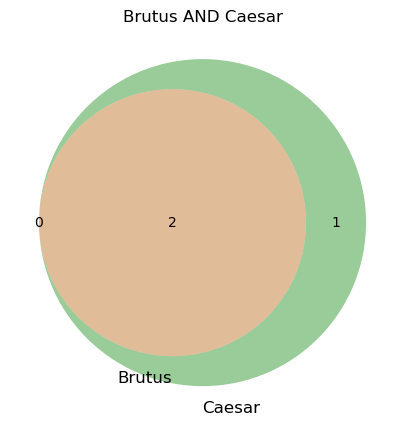

In [10]:
from matplotlib_venn import venn2

# Example: Brutus vs Caesar
plt.figure(figsize=(5,5))
venn2([set(inverted_index["brutus"]), set(inverted_index["caesar"])],
      set_labels=("Brutus", "Caesar"))
plt.title("Brutus AND Caesar")
plt.show()


- Boolean retrieval = **Exact Match**
- Docs either satisfy the query or not (binary relevance)
- Uses **set operations** on postings lists
- **Pros:** precise, transparent, controllable
- **Cons:** too rigid, unranked, unfriendly for casual users
- This limitation led to **Best Match retrieval**, where documents are ranked (next lecture!)


# Exact Match vs Best Match

In [21]:
import re

def boolean_query_and_not(docs, must_include, must_exclude):
    results = []
    for doc_id, text in docs.items():
        text_lower = text.lower()
        if all(term.lower() in text_lower for term in must_include) and \
           all(term.lower() not in text_lower for term in must_exclude):
            results.append(doc_id)
    return results

# Example query: Brutus AND Caesar AND NOT Calpurnia
exact_results = boolean_query_and_not(documents, ["brutus", "caesar"], ["calpurnia"])

print("Boolean (Exact Match) Results:")
for doc_id in exact_results:
    print(f"Doc {doc_id}: {documents[doc_id]}")


Boolean (Exact Match) Results:
Doc 1: Brutus and Caesar were seen in the marketplace.
Doc 5: Brutus plotted against Caesar with the conspirators.


In [22]:
from collections import Counter

def best_match_overlap(docs, query_terms):
    scores = {}
    for doc_id, text in docs.items():
        tokens = re.findall(r'\b\w+\b', text.lower())
        overlap = sum(tokens.count(q.lower()) for q in query_terms)
        scores[doc_id] = overlap
    
    # Sort by score (highest first)
    results = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [(doc_id, score) for doc_id, score in results if score > 0]

# Same query words, but treated as a bag of terms
best_results = best_match_overlap(documents, ["brutus", "caesar", "calpurnia"])

print("\nBest Match Results (Ranked by overlap):")
for doc_id, score in best_results:
    print(f"Doc {doc_id} (score={score}): {documents[doc_id]}")



Best Match Results (Ranked by overlap):
Doc 1 (score=2): Brutus and Caesar were seen in the marketplace.
Doc 2 (score=2): Calpurnia warned Caesar about the ides of March.
Doc 5 (score=2): Brutus plotted against Caesar with the conspirators.


- Exact Match correctly excludes Doc 2 because of NOT Calpurnia.

- Best Match ranks Doc 2 equally with Docs 1 and 5 — failing the user’s real intent.

- Lesson: Best Match is flexible, but when constraints matter (NOT conditions), Boolean retrieval is necessary.